# Подключаем библиотеки

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
import kagglehub
import os

c:\study\OOD\OOD\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
dir_path = kagglehub.dataset_download("fedesoriano/stellar-classification-dataset-sdss17")
csv_filename = 'star_classification.csv'
full_file_path = os.path.join(dir_path, csv_filename)
df = pd.read_csv(full_file_path)
df

,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,class,redshift,plate,MJD,fiber_ID
0,1.237661e+18,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,3606,301,2,79,6.543777e+18,GALAXY,0.634794,5812,56354,171
1,1.237665e+18,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,4518,301,5,119,1.176014e+19,GALAXY,0.779136,10445,58158,427
2,1.237661e+18,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,3606,301,2,120,5.152200e+18,GALAXY,0.644195,4576,55592,299
3,1.237663e+18,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,4192,301,3,214,1.030107e+19,GALAXY,0.932346,9149,58039,775
4,1.237680e+18,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,8102,301,3,137,6.891865e+18,GALAXY,0.116123,6121,56187,842
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,1.237679e+18,39.620709,-2.594074,22.16759,22.97586,21.90404,21.30548,20.73569,7778,301,2,581,1.055431e+19,GALAXY,0.000000,9374,57749,438
99996,1.237679e+18,29.493819,19.798874,22.69118,22.38628,20.45003,19.75759,19.41526,7917,301,1,289,8.586351e+18,GALAXY,0.404895,7626,56934,866
99997,1.237668e+18,224.587407,15.700707,21.16916,19.26997,18.20428,17.69034,17.35221,5314,301,4,308,3.112008e+18,GALAXY,0.143366,2764,54535,74
99998,1.237661e+18,212.268621,46.660365,25.35039,21.63757,19.91386,19.07254,18.62482,3650,301,4,131,7.601080e+18,GALAXY,0.455040,6751,56368,470


- Датасет содержит в себе 100000 объектов, описанных 18 признаками

# Первичный анализ датасета

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 18 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   obj_ID       100000 non-null  float64
 1   alpha        100000 non-null  float64
 2   delta        100000 non-null  float64
 3   u            100000 non-null  float64
 4   g            100000 non-null  float64
 5   r            100000 non-null  float64
 6   i            100000 non-null  float64
 7   z            100000 non-null  float64
 8   run_ID       100000 non-null  int64  
 9   rerun_ID     100000 non-null  int64  
 10  cam_col      100000 non-null  int64  
 11  field_ID     100000 non-null  int64  
 12  spec_obj_ID  100000 non-null  float64
 13  class        100000 non-null  object 
 14  redshift     100000 non-null  float64
 15  plate        100000 non-null  int64  
 16  MJD          100000 non-null  int64  
 17  fiber_ID     100000 non-null  int64  
dtypes: float64(10), int64(7),

- В датасете нет пропусков
- Большинство признаков представлены числами, кроме целевого признака (*class*)

In [4]:
df.describe()

,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,redshift,plate,MJD,fiber_ID
count,1.000000e+05,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.0,100000.000000,100000.000000,1.000000e+05,100000.000000,100000.000000,100000.000000,100000.000000
mean,1.237665e+18,177.629117,24.135305,21.980468,20.531387,19.645762,19.084854,18.668810,4481.366060,301.0,3.511610,186.130520,5.783882e+18,0.576661,5137.009660,55588.647500,449.312740
std,8.438560e+12,96.502241,19.644665,31.769291,31.750292,1.854760,1.757895,31.728152,1964.764593,0.0,1.586912,149.011073,3.324016e+18,0.730707,2952.303351,1808.484233,272.498404
min,1.237646e+18,0.005528,-18.785328,-9999.000000,-9999.000000,9.822070,9.469903,-9999.000000,109.000000,301.0,1.000000,11.000000,2.995191e+17,-0.009971,266.000000,51608.000000,1.000000
25%,1.237659e+18,127.518222,5.146771,20.352353,18.965230,18.135828,17.732285,17.460677,3187.000000,301.0,2.000000,82.000000,2.844138e+18,0.054517,2526.000000,54234.000000,221.000000
50%,1.237663e+18,180.900700,23.645922,22.179135,21.099835,20.125290,19.405145,19.004595,4188.000000,301.0,4.000000,146.000000,5.614883e+18,0.424173,4987.000000,55868.500000,433.000000
75%,1.237668e+18,233.895005,39.901550,23.687440,22.123767,21.044785,20.396495,19.921120,5326.000000,301.0,5.000000,241.000000,8.332144e+18,0.704154,7400.250000,56777.000000,645.000000
max,1.237681e+18,359.999810,83.000519,32.781390,31.602240,29.571860,32.141470,29.383740,8162.000000,301.0,6.000000,989.000000,1.412694e+19,7.011245,12547.000000,58932.000000,1000.000000


In [5]:
df.loc[:,'class'].value_counts()

class
GALAXY    59445
STAR      21594
QSO       18961
Name: count, dtype: int64

- Признак *class* содержит 3 разных значения, тогда получается задача является не бинарной а многоклассовой классификацией
- По условию лабораторной работы у нас бинарная классификация, поэтому всё, что не является звездой пометим как 0, а звезду как 1

In [6]:
mapping = {
    'STAR' : 1,
    'GALAXY' : 0,
    'QSO' : 0
}
df = df.replace({'class': mapping})
df['class'].value_counts()

C:\Users\dybal\AppData\Local\Temp\ipykernel_4496\272235918.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace({'class': mapping})


class
0    78406
1    21594
Name: count, dtype: int64

- Теперь вё в порядке можем работать дальше

In [7]:
df.duplicated().sum()

np.int64(0)

# Корреляционные матрицы (Пирсона и Спирмана)

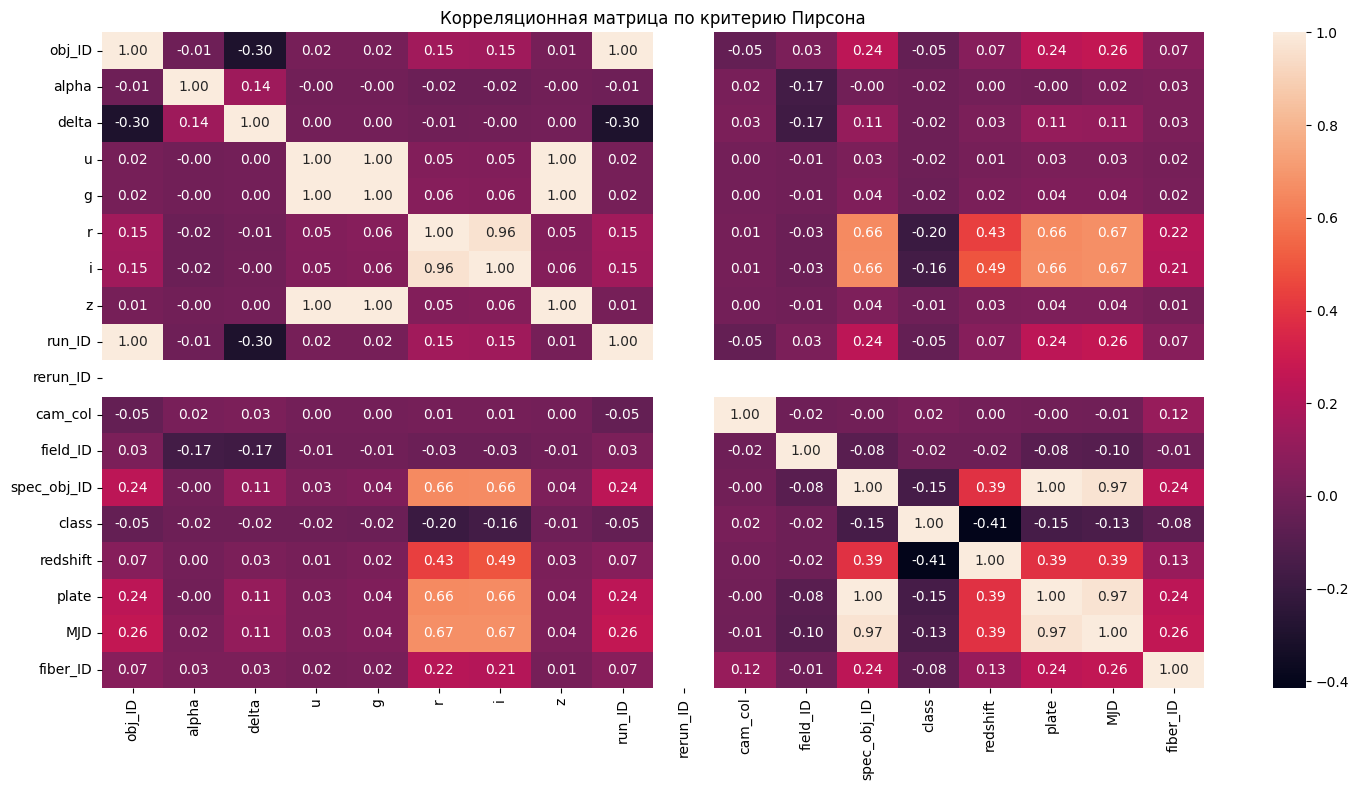

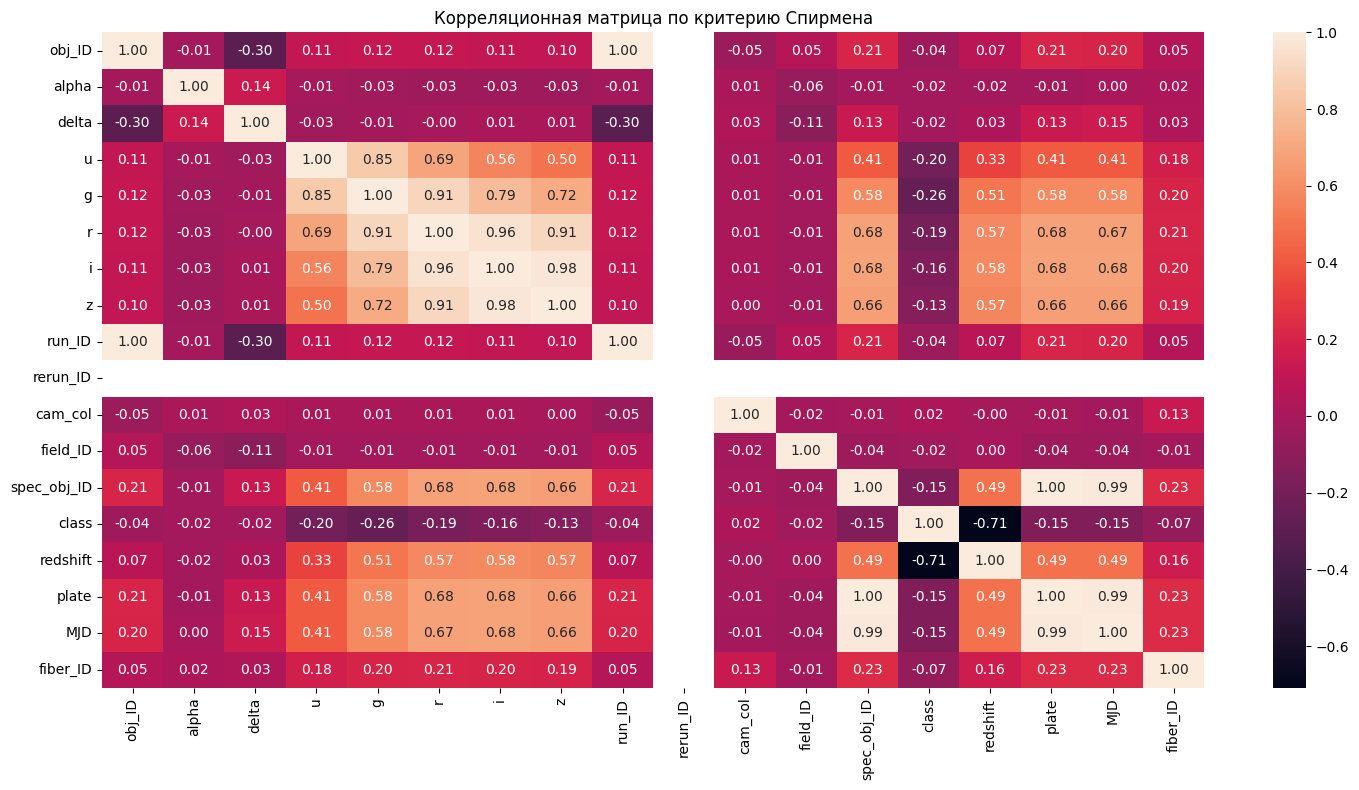

In [8]:
pearson_corr = df.corr(numeric_only=True)
spearman_corr = df.corr(method='spearman', numeric_only=True)

plt.figure(figsize=(15, 8))
sns.heatmap(pearson_corr, fmt='.2f', annot=True)
plt.title('Корреляционная матрица по критерию Пирсона')
plt.tight_layout()
plt.show()

plt.figure(figsize=(15, 8))

sns.heatmap(spearman_corr, fmt='.2f', annot=True)
plt.title('Корреляционная матрица по критерию Спирмена')
plt.tight_layout()
plt.show()

- Первое что мы можем увидеть это мультиколлинеарность, что не очень хорошо, возможно в последующем прид1тся избавиться от некоторых признаков, а может быть воспользуемся понижением размерности(PCA)
- Далее из матрицы Пирсона мы видим, что целевой признак *class* имеет отрицательные линейные корреляции
- Матрица Спирмена показывает нелинейные отрицательные корреляции с признаками *u*, *g*, *r*, *i*, *z*, *spec_obj_ID*, *redshift*, *plate*, *MJD*, и *fiber_ID* - это будут признаки-кандидаты для обучения

In [9]:

feature_candidates = ['u', 'g', 'r', 'i', 'z', 'spec_obj_ID', 'redshift', 'plate', 'MJD', 'fiber_ID', 'class']
features_to_drop = [feature for feature in df.columns if feature not in feature_candidates]
df = df.drop(features_to_drop, axis=1)
df

,u,g,r,i,z,spec_obj_ID,class,redshift,plate,MJD,fiber_ID
0,23.87882,22.27530,20.39501,19.16573,18.79371,6.543777e+18,0,0.634794,5812,56354,171
1,24.77759,22.83188,22.58444,21.16812,21.61427,1.176014e+19,0,0.779136,10445,58158,427
2,25.26307,22.66389,20.60976,19.34857,18.94827,5.152200e+18,0,0.644195,4576,55592,299
3,22.13682,23.77656,21.61162,20.50454,19.25010,1.030107e+19,0,0.932346,9149,58039,775
4,19.43718,17.58028,16.49747,15.97711,15.54461,6.891865e+18,0,0.116123,6121,56187,842
...,...,...,...,...,...,...,...,...,...,...,...
99995,22.16759,22.97586,21.90404,21.30548,20.73569,1.055431e+19,0,0.000000,9374,57749,438
99996,22.69118,22.38628,20.45003,19.75759,19.41526,8.586351e+18,0,0.404895,7626,56934,866
99997,21.16916,19.26997,18.20428,17.69034,17.35221,3.112008e+18,0,0.143366,2764,54535,74
99998,25.35039,21.63757,19.91386,19.07254,18.62482,7.601080e+18,0,0.455040,6751,56368,470


- Оставляем признаки с высоким абсолютным значением корреляции Спирмена, дальше ещё раз посмотрим на корреляционную матрицу, чтобы выявить мультиколлинеарности

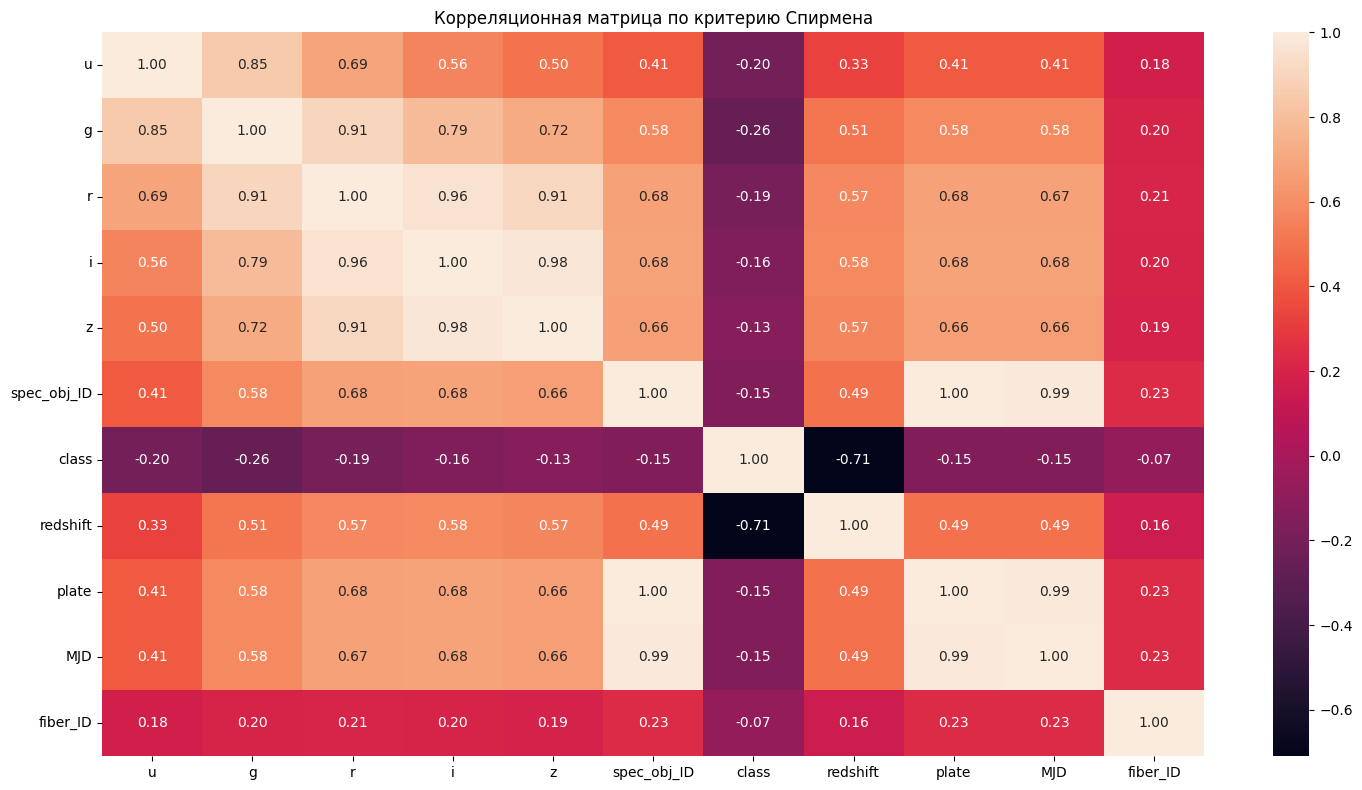

In [10]:
plt.figure(figsize=(15, 8))
spearman_corr = df.corr(method='spearman', numeric_only=True)
sns.heatmap(spearman_corr, fmt='.2f', annot=True)
plt.title('Корреляционная матрица по критерию Спирмена')
plt.tight_layout()
plt.show()

- Да, у нас много коррелирующих между собой признаков, однако удалять мы их не будем, прочитав условия соревнования понимаем, что друг без друга эти признаки не несут полезной информации. Возможно мы можем удалить айдишники, так как большой информации они тоже не несут

In [11]:
df = df.drop(['fiber_ID', 'spec_obj_ID'], axis=1)
df

,u,g,r,i,z,class,redshift,plate,MJD
0,23.87882,22.27530,20.39501,19.16573,18.79371,0,0.634794,5812,56354
1,24.77759,22.83188,22.58444,21.16812,21.61427,0,0.779136,10445,58158
2,25.26307,22.66389,20.60976,19.34857,18.94827,0,0.644195,4576,55592
3,22.13682,23.77656,21.61162,20.50454,19.25010,0,0.932346,9149,58039
4,19.43718,17.58028,16.49747,15.97711,15.54461,0,0.116123,6121,56187
...,...,...,...,...,...,...,...,...,...
99995,22.16759,22.97586,21.90404,21.30548,20.73569,0,0.000000,9374,57749
99996,22.69118,22.38628,20.45003,19.75759,19.41526,0,0.404895,7626,56934
99997,21.16916,19.26997,18.20428,17.69034,17.35221,0,0.143366,2764,54535
99998,25.35039,21.63757,19.91386,19.07254,18.62482,0,0.455040,6751,56368


- Прочитав ещё раз описание данных, мы можем удалить признак *MJD* (это какая-то там модифицированная дата по юлианскому календарю, которая тоже не может чисто логически влиять на то, будет объект звездой или нет)
- Так же можем удалить *plate*, т.к. это оказывается тоже айдишник.
В итоге остаются лишь несколько признаков, описывающих звезду

In [12]:
df = df.drop(['MJD', 'plate'], axis=1)
df

,u,g,r,i,z,class,redshift
0,23.87882,22.27530,20.39501,19.16573,18.79371,0,0.634794
1,24.77759,22.83188,22.58444,21.16812,21.61427,0,0.779136
2,25.26307,22.66389,20.60976,19.34857,18.94827,0,0.644195
3,22.13682,23.77656,21.61162,20.50454,19.25010,0,0.932346
4,19.43718,17.58028,16.49747,15.97711,15.54461,0,0.116123
...,...,...,...,...,...,...,...
99995,22.16759,22.97586,21.90404,21.30548,20.73569,0,0.000000
99996,22.69118,22.38628,20.45003,19.75759,19.41526,0,0.404895
99997,21.16916,19.26997,18.20428,17.69034,17.35221,0,0.143366
99998,25.35039,21.63757,19.91386,19.07254,18.62482,0,0.455040


In [13]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
y = df.loc[:,'class']
X = df.drop(['class'], axis=1)
scaler = MinMaxScaler()
X = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=True)

- Приводим значения признаков к одному масштабу и делим датасет на train и test

In [49]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(penalty='l2', class_weight='balanced')
model.fit(X_train, y_train)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


- Решил использовать l2 регуляризацию
- class_weight = 'balanced' для того, чтобы модель больше ориентировалась на меньший класс (так как классы у нас несбалансированны)

In [50]:
preds = model.predict(X_test)

In [51]:
from sklearn.metrics import accuracy_score, precision_score, recall_score

print(f'Accuracy: {accuracy_score(y_test, preds)}')
print(f'Precision: {precision_score(y_test, preds)}')
print(f'Recall: {recall_score(y_test, preds)}')


Accuracy: 0.9103
Precision: 0.7113152804642167
Recall: 0.9993206521739131


- Наблюдаем высокое значение полноты, это значит что модель смогла распознать практически все звёзды, однако точность 0.71 означает, что много НЕ звёзд было классифицированно ошибочко как звёзды. На самом деле произошло это из-за параметра class_weigths
- Убрав параметр class_weights фиксируем следующие результаты:

    - Accuracy: 0.963
    - Precision: 0.921559633027523
    - Recall: 0.9098731884057971

In [93]:
from keras.models import Sequential
from keras.layers import Input, Dense
from keras.regularizers import l2
from keras.activations import sigmoid, leaky_relu
from keras.losses import binary_crossentropy

model = Sequential()
model.add(Input(shape=(X_train.shape[1], )))
model.add(Dense(units=16, activation=leaky_relu, kernel_regularizer=l2))
model.add(Dense(units=32, activation=leaky_relu, kernel_regularizer=l2))
model.add(Dense(units=1, activation=sigmoid))

model.compile(optimizer='adam', loss=binary_crossentropy)
model.fit(x=X_train, y=y_train, batch_size=64, epochs=15)


Epoch 1/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 1s 667us/step - loss: 0.5480
Epoch 2/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 1s 661us/step - loss: 0.4046
Epoch 3/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 1s 666us/step - loss: 0.3362
Epoch 4/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 1s 689us/step - loss: 0.3032
Epoch 5/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 1s 667us/step - loss: 0.2808
Epoch 6/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 1s 661us/step - loss: 0.2635
Epoch 7/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 1s 658us/step - loss: 0.2492
Epoch 8/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 1s 663us/step - loss: 0.2374
Epoch 9/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 1s 690us/step - loss: 0.2278
Epoch 10/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 1s 681us/step - loss: 0.2183
Epoch 11/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 1s 676us/step - loss: 0.2108
Epoch 12/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 1s 667us/step - loss: 0.2037
Epoch 13/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 1s 698us/step - loss: 0.1977
Epoch 14/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 1s 665us/step - loss: 0.1919
E

In [94]:
preds = model.predict(X_test)


625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 463us/step


In [95]:
preds_classes = (preds >= 0.5).astype(int)

In [96]:
print(f'Accuracy: {accuracy_score(y_test, preds_classes)}')
print(f'Precision: {precision_score(y_test, preds_classes)}')
print(f'Recall: {recall_score(y_test, preds_classes)}')

Accuracy: 0.977
Precision: 0.9281385281385282
Recall: 0.9710144927536232
